In [ ]:
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"
print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes


In [ ]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("titanic")
print("Data shape:", df.shape)
print(df.head())

Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop_duplicates(inplace=True)
df = pd.get_dummies(df, columns=['sex', 'class', 'embarked'], drop_first=True)
df['family_size'] = df['sibsp'] + df['parch']
print(df.head())

   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

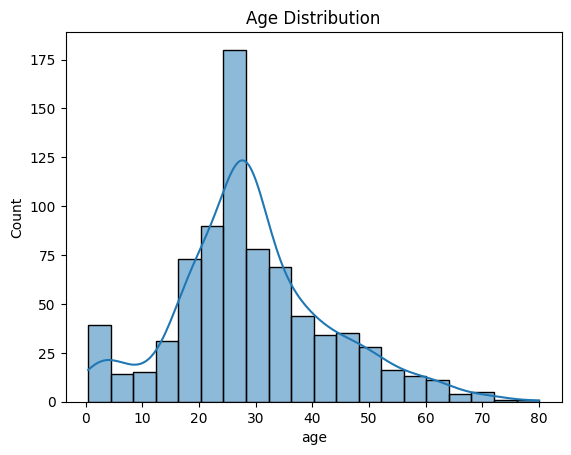

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

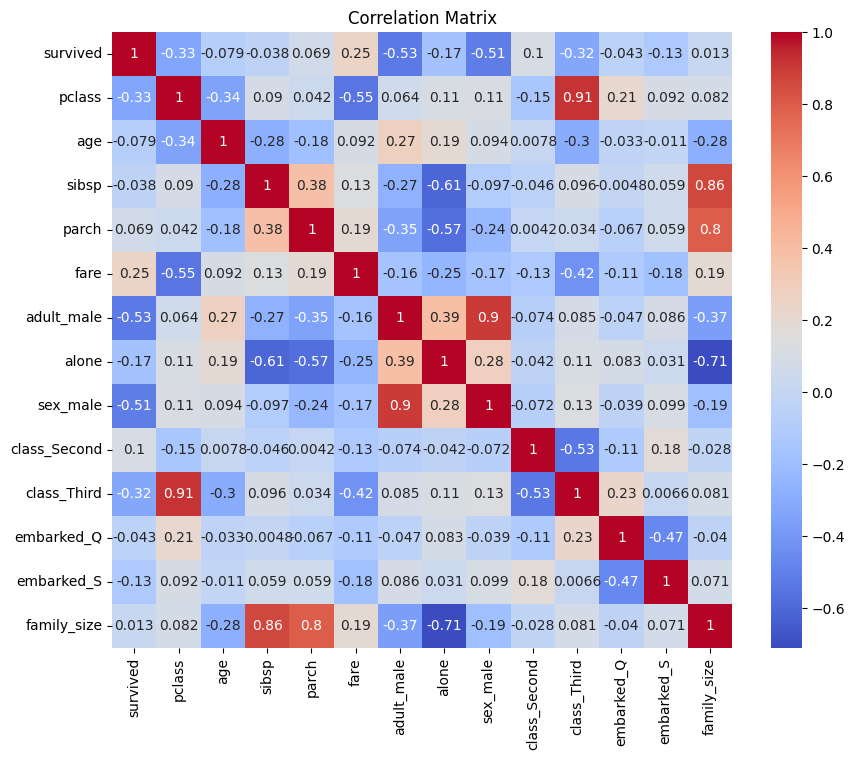

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
model_df = df.drop(columns=['alive'], errors='ignore')
model_df = pd.get_dummies(model_df, drop_first=True)
X = model_df.drop(columns=['survived'])
y = model_df['survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.802547770700637
Precision: 0.8135593220338984
Recall: 0.7058823529411765
Confusion Matrix:
 [[78 11]
 [20 48]]
